**Import Dataset**

In [1]:
import pandas as pd
df = pd.read_csv('/content/Health_Risk_Dataset.csv')
df.head()

,Patient_ID,Respiratory_Rate,Oxygen_Saturation,O2_Scale,Systolic_BP,Heart_Rate,Temperature,Consciousness,On_Oxygen,Risk_Level
0,P0522,25,96,1,97,107,37.5,A,0,Medium
1,P0738,28,92,2,116,151,38.5,P,1,High
2,P0741,29,91,1,79,135,38.4,A,0,High
3,P0661,24,96,1,95,92,37.3,A,0,Medium
4,P0412,20,96,1,97,97,37.4,A,0,Low


**PreProcessing**



In [2]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Patient_ID         1000 non-null   object 
 1   Respiratory_Rate   1000 non-null   int64  
 2   Oxygen_Saturation  1000 non-null   int64  
 3   O2_Scale           1000 non-null   int64  
 4   Systolic_BP        1000 non-null   int64  
 5   Heart_Rate         1000 non-null   int64  
 6   Temperature        1000 non-null   float64
 7   Consciousness      1000 non-null   object 
 8   On_Oxygen          1000 non-null   int64  
 9   Risk_Level         1000 non-null   object 
dtypes: float64(1), int64(6), object(3)
memory usage: 78.3+ KB


In [3]:
print (df.shape)

(1000, 10)


In [4]:
print (df.info)

<bound method DataFrame.info of     Patient_ID  Respiratory_Rate  Oxygen_Saturation  O2_Scale  Systolic_BP  \
0        P0522                25                 96         1           97   
1        P0738                28                 92         2          116   
2        P0741                29                 91         1           79   
3        P0661                24                 96         1           95   
4        P0412                20                 96         1           97   
..         ...               ...                ...       ...          ...   
995      P0107                18                 96         1          124   
996      P0271                19                 95         1          129   
997      P0861                39                 82         1          101   
998      P0436                15                 92         1          106   
999      P0103                16                 97         1          130   

     Heart_Rate  Temperature Co

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Patient_ID         1000 non-null   object 
 1   Respiratory_Rate   1000 non-null   int64  
 2   Oxygen_Saturation  1000 non-null   int64  
 3   O2_Scale           1000 non-null   int64  
 4   Systolic_BP        1000 non-null   int64  
 5   Heart_Rate         1000 non-null   int64  
 6   Temperature        1000 non-null   float64
 7   Consciousness      1000 non-null   object 
 8   On_Oxygen          1000 non-null   int64  
 9   Risk_Level         1000 non-null   object 
dtypes: float64(1), int64(6), object(3)
memory usage: 78.3+ KB


In [6]:
df.describe()

,Respiratory_Rate,Oxygen_Saturation,O2_Scale,Systolic_BP,Heart_Rate,Temperature,On_Oxygen
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,21.511000,92.59000,1.124000,106.160000,98.460000,37.921000,0.274000
std,5.287517,4.47302,0.329746,17.897562,19.694626,1.113696,0.446232
min,12.000000,74.00000,1.000000,50.000000,60.000000,35.600000,0.000000
25%,17.000000,90.00000,1.000000,94.000000,84.000000,37.100000,0.000000
50%,20.000000,94.00000,1.000000,109.000000,95.500000,37.800000,0.000000
75%,25.000000,96.00000,1.000000,119.000000,109.000000,38.600000,1.000000
max,40.000000,100.00000,2.000000,146.000000,163.000000,41.800000,1.000000


In [7]:
df.isna().sum()

,0
Patient_ID,0
Respiratory_Rate,0
Oxygen_Saturation,0
O2_Scale,0
Systolic_BP,0
Heart_Rate,0
Temperature,0
Consciousness,0
On_Oxygen,0
Risk_Level,0


In [8]:
df.isnull().sum()


,0
Patient_ID,0
Respiratory_Rate,0
Oxygen_Saturation,0
O2_Scale,0
Systolic_BP,0
Heart_Rate,0
Temperature,0
Consciousness,0
On_Oxygen,0
Risk_Level,0


In [9]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)


/tmp/ipykernel_4191/3736601534.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [10]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)


/tmp/ipykernel_4191/3086599729.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [11]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)


In [12]:
df.dtypes

,0
Patient_ID,object
Respiratory_Rate,int64
Oxygen_Saturation,int64
O2_Scale,int64
Systolic_BP,int64
Heart_Rate,int64
Temperature,float64
Consciousness,object
On_Oxygen,int64
Risk_Level,object


In [13]:
df['Patient_ID'] = df['Patient_ID'].astype('string')


In [14]:
df.dtypes

,0
Patient_ID,string[python]
Respiratory_Rate,int64
Oxygen_Saturation,int64
O2_Scale,int64
Systolic_BP,int64
Heart_Rate,int64
Temperature,float64
Consciousness,object
On_Oxygen,int64
Risk_Level,object


In [15]:
df['Risk_Level'].value_counts()


,count
Risk_Level,
Medium,306
High,279
Low,255
Normal,160


In [16]:
df['Risk_Level'] = df['Risk_Level'].map({
    'Normal': 0, # Assuming 'Normal' is the lowest risk category
    'Low': 1,
    'Medium': 2,
    'High': 3
})

In [17]:
df['Consciousness'].value_counts()


,count
Consciousness,
A,914
V,33
U,26
P,20
C,7


In [18]:
df.dtypes
df.head()

,Patient_ID,Respiratory_Rate,Oxygen_Saturation,O2_Scale,Systolic_BP,Heart_Rate,Temperature,Consciousness,On_Oxygen,Risk_Level
0,P0522,25,96,1,97,107,37.5,A,0,2
1,P0738,28,92,2,116,151,38.5,P,1,3
2,P0741,29,91,1,79,135,38.4,A,0,3
3,P0661,24,96,1,95,92,37.3,A,0,2
4,P0412,20,96,1,97,97,37.4,A,0,1


In [19]:
df['Consciousness'].unique()


array(['A', 'P', 'V', 'U', 'C'], dtype=object)

In [20]:
df['Consciousness'] = df['Consciousness'].astype(str)


In [21]:
df['Consciousness'] = df['Consciousness'].map({
    'A': 0,  # Alert
    'C': 1,  # Confused
    'V': 2,  # Voice
    'P': 3,  # Pain
    'U': 4   # Unresponsive
})


In [22]:
df.dtypes
df.head()

,Patient_ID,Respiratory_Rate,Oxygen_Saturation,O2_Scale,Systolic_BP,Heart_Rate,Temperature,Consciousness,On_Oxygen,Risk_Level
0,P0522,25,96,1,97,107,37.5,0,0,2
1,P0738,28,92,2,116,151,38.5,3,1,3
2,P0741,29,91,1,79,135,38.4,0,0,3
3,P0661,24,96,1,95,92,37.3,0,0,2
4,P0412,20,96,1,97,97,37.4,0,0,1


In [23]:
df.tail()

,Patient_ID,Respiratory_Rate,Oxygen_Saturation,O2_Scale,Systolic_BP,Heart_Rate,Temperature,Consciousness,On_Oxygen,Risk_Level
995,P0107,18,96,1,124,72,37.2,0,0,0
996,P0271,19,95,1,129,70,38.1,0,0,1
997,P0861,39,82,1,101,137,37.5,0,1,3
998,P0436,15,92,1,106,108,38.6,0,0,2
999,P0103,16,97,1,130,76,36.4,0,0,0


In [24]:
print(df['Consciousness'].unique())
print(df.isna().sum())
print(df.dtypes)


[0 3 2 4 1]
Patient_ID           0
Respiratory_Rate     0
Oxygen_Saturation    0
O2_Scale             0
Systolic_BP          0
Heart_Rate           0
Temperature          0
Consciousness        0
On_Oxygen            0
Risk_Level           0
dtype: int64
Patient_ID           string[python]
Respiratory_Rate              int64
Oxygen_Saturation             int64
O2_Scale                      int64
Systolic_BP                   int64
Heart_Rate                    int64
Temperature                 float64
Consciousness                 int64
On_Oxygen                     int64
Risk_Level                    int64
dtype: object


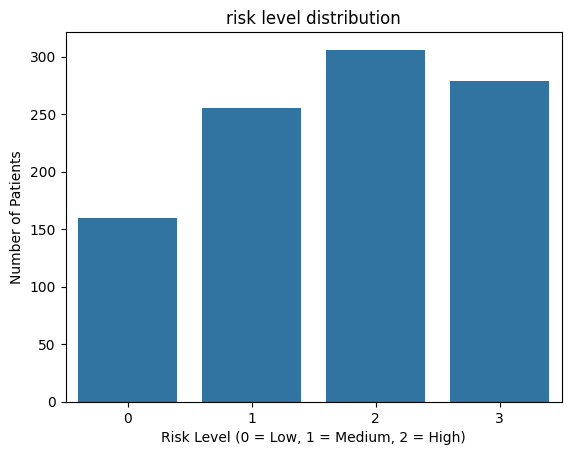

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Risk_Level',data=df)
plt.title('risk level distribution')
plt.xlabel('Risk Level (0 = Low, 1 = Medium, 2 = High)')
plt.ylabel('Number of Patients')
plt.show()

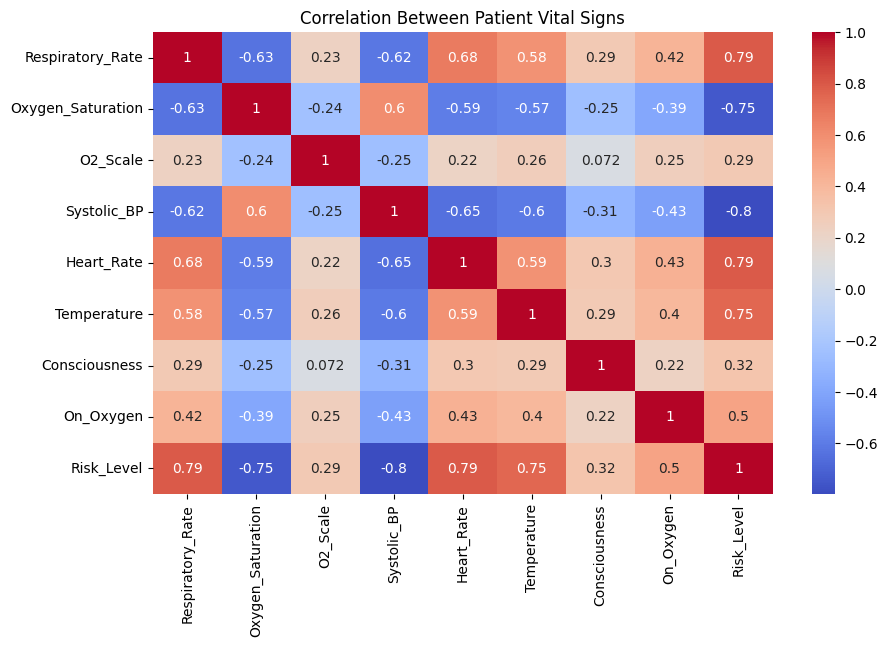

In [26]:
plt.figure(figsize=(10,6))
sns.heatmap(df.drop(columns=['Patient_ID']).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Between Patient Vital Signs')
plt.show()


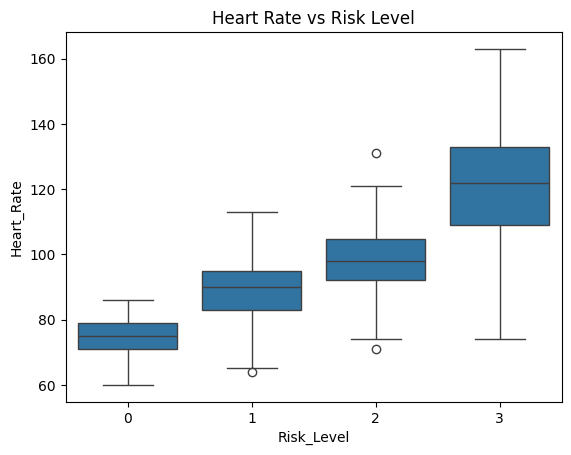

In [27]:
sns.boxplot(x='Risk_Level', y='Heart_Rate', data=df)
plt.title('Heart Rate vs Risk Level')
plt.show()


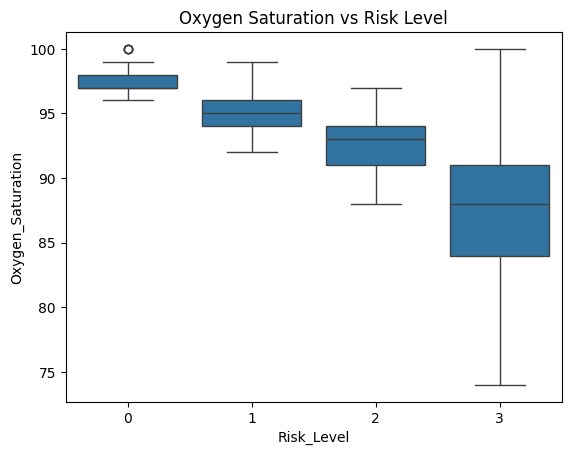

In [28]:
sns.boxplot(x='Risk_Level', y='Oxygen_Saturation', data=df)
plt.title('Oxygen Saturation vs Risk Level')
plt.show()


In [29]:
df_model = df.copy()
df_model.head()


,Patient_ID,Respiratory_Rate,Oxygen_Saturation,O2_Scale,Systolic_BP,Heart_Rate,Temperature,Consciousness,On_Oxygen,Risk_Level
0,P0522,25,96,1,97,107,37.5,0,0,2
1,P0738,28,92,2,116,151,38.5,3,1,3
2,P0741,29,91,1,79,135,38.4,0,0,3
3,P0661,24,96,1,95,92,37.3,0,0,2
4,P0412,20,96,1,97,97,37.4,0,0,1


In [30]:
df_model = df.copy()

X = df_model.drop(columns=['Risk_Level', 'Patient_ID'])
y = df_model['Risk_Level']


In [31]:
df_model.head()

,Patient_ID,Respiratory_Rate,Oxygen_Saturation,O2_Scale,Systolic_BP,Heart_Rate,Temperature,Consciousness,On_Oxygen,Risk_Level
0,P0522,25,96,1,97,107,37.5,0,0,2
1,P0738,28,92,2,116,151,38.5,3,1,3
2,P0741,29,91,1,79,135,38.4,0,0,3
3,P0661,24,96,1,95,92,37.3,0,0,2
4,P0412,20,96,1,97,97,37.4,0,0,1


In [32]:
df['Risk_Level'].unique()


array([2, 3, 1, 0])

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


TRAIN MACHINE LEARNING MODELS

Model 1: Logistic Regression

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.955
              precision    recall  f1-score   support

           0       0.94      0.97      0.95        32
           1       0.92      0.92      0.92        51
           2       0.95      0.95      0.95        61
           3       1.00      0.98      0.99        56

    accuracy                           0.95       200
   macro avg       0.95      0.96      0.95       200
weighted avg       0.96      0.95      0.96       200



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [35]:
from sklearn.metrics import accuracy_score

lr_accuracy = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {lr_accuracy * 100:.2f}%")


Logistic Regression Accuracy: 95.50%


Model 2: Random Forest

In [36]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.965
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        32
           1       0.93      0.98      0.95        51
           2       0.95      0.95      0.95        61
           3       1.00      0.96      0.98        56

    accuracy                           0.96       200
   macro avg       0.97      0.97      0.97       200
weighted avg       0.97      0.96      0.97       200



In [37]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {rf_accuracy * 100:.2f}%")


Random Forest Accuracy: 96.50%


MODEL 3: Decision Tree Classifier

In [38]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {dt_accuracy * 100:.2f}%")
print(classification_report(y_test, y_pred_dt))


Decision Tree Accuracy: 91.00%
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        32
           1       0.90      0.88      0.89        51
           2       0.84      0.89      0.86        61
           3       0.95      0.93      0.94        56

    accuracy                           0.91       200
   macro avg       0.92      0.92      0.92       200
weighted avg       0.91      0.91      0.91       200



In [39]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Train Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Predict
y_pred_dt = dt.predict(X_test)

# Accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {dt_accuracy * 100:.2f}%")

# Optional: detailed report
print(classification_report(y_test, y_pred_dt))


Decision Tree Accuracy: 91.00%
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        32
           1       0.90      0.88      0.89        51
           2       0.84      0.89      0.86        61
           3       0.95      0.93      0.94        56

    accuracy                           0.91       200
   macro avg       0.92      0.92      0.92       200
weighted avg       0.91      0.91      0.91       200



MODEL 4: Support Vector Machine (SVM)

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [41]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)

svm_accuracy = accuracy_score(y_test, y_pred_svm)
print(f"SVM Accuracy: {svm_accuracy * 100:.2f}%")
print(classification_report(y_test, y_pred_svm))


SVM Accuracy: 95.00%
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        32
           1       0.92      0.92      0.92        51
           2       0.92      0.95      0.94        61
           3       1.00      0.96      0.98        56

    accuracy                           0.95       200
   macro avg       0.95      0.95      0.95       200
weighted avg       0.95      0.95      0.95       200



FINAL MODEL COMPARISON TABLE

In [42]:
import pandas as pd

final_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Decision Tree',
        'Support Vector Machine'
    ],
    'Accuracy (%)': [
        lr_accuracy * 100,
        rf_accuracy * 100,
        dt_accuracy * 100,
        svm_accuracy * 100
    ]
})

final_results


,Model,Accuracy (%)
0,Logistic Regression,95.5
1,Random Forest,96.5
2,Decision Tree,91.0
3,Support Vector Machine,95.0


BUILD THE PREDICTIVE SYSTEM

In [43]:
final_model = rf


In [44]:
def predict_patient_risk(input_data):
    """
    input_data: list of patient vitals in correct order
    """
    input_array = np.array(input_data).reshape(1, -1)
    prediction = final_model.predict(input_array)[0]

    if prediction == 0:
        return "LOW RISK 🟢 – Routine monitoring recommended"
    elif prediction == 1:
        return "MEDIUM RISK 🟡 – Doctor review advised"
    else:
        return "HIGH RISK 🔴 – Immediate medical attention required"


In [45]:
X.columns


Index(['Respiratory_Rate', 'Oxygen_Saturation', 'O2_Scale', 'Systolic_BP',
       'Heart_Rate', 'Temperature', 'Consciousness', 'On_Oxygen'],
      dtype='object')

In [46]:
import numpy as np


In [47]:
sample_patient = [
    20,    # Respiratory_Rate
    95,    # Oxygen_Saturation
    1,     # O2_Scale
    130,   # Systolic_BP
    110,   # Heart_Rate
    38.5,  # Temperature
    3,     # Consciousness (P)
    1      # On_Oxygen
]

result = predict_patient_risk(sample_patient)
print(result)


HIGH RISK 🔴 – Immediate medical attention required


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [48]:
import gradio as gr
import numpy as np

# Redefine predict_patient_risk to align output messages with the Risk_Level mapping (0=Normal, 1=Low, 2=Medium, 3=High)
def predict_patient_risk(input_data):
    """
    input_data: list of patient vitals in correct order
    """
    input_array = np.array(input_data).reshape(1, -1)
    prediction = final_model.predict(input_array)[0]

    if prediction == 0:
        return "NORMAL RISK ✅ – Routine monitoring recommended"
    elif prediction == 1:
        return "LOW RISK 🟢 – Routine monitoring recommended"
    elif prediction == 2:
        return "MEDIUM RISK 🟡 – Doctor review advised"
    elif prediction == 3:
        return "HIGH RISK 🔴 – Immediate medical attention required"
    else:
        return "UNKNOWN RISK LEVEL" # Should not happen with current mapping

# Define a mapping for consciousness for the Gradio interface, using readable labels
consciousness_mapping = {
    'Alert (A)': 0,
    'Confused (C)': 1,
    'Voice (V)': 2,
    'Pain (P)': 3,
    'Unresponsive (U)': 4
}

# Create a wrapper function to handle Gradio inputs and call the prediction function
def gradio_predict_patient_risk(
    respiratory_rate,
    oxygen_saturation,
    o2_scale,
    systolic_bp,
    heart_rate,
    temperature,
    consciousness_str, # This will be the string from Gradio
    on_oxygen # This will be a boolean from Gradio
):
    # Convert consciousness string back to its numerical representation
    consciousness_val = consciousness_mapping[consciousness_str]

    # Convert on_oxygen boolean to 0 or 1
    on_oxygen_val = 1 if on_oxygen else 0

    input_data = [
        respiratory_rate,
        oxygen_saturation,
        o2_scale,
        systolic_bp,
        heart_rate,
        temperature,
        consciousness_val,
        on_oxygen_val
    ]
    return predict_patient_risk(input_data)

# Define Gradio input components based on X.columns and their ranges
# Ranges are inferred from df.describe() in previous executed cells
inputs = [
    gr.Slider(minimum=12, maximum=40, value=20, step=1, label="Respiratory Rate (breaths/min)"),
    gr.Slider(minimum=74, maximum=100, value=95, step=1, label="Oxygen Saturation (%)"),
    gr.Radio([1, 2], value=1, label="O2 Scale (1 or 2)"),
    gr.Slider(minimum=50, maximum=146, value=130, step=1, label="Systolic BP (mmHg)"),
    gr.Slider(minimum=60, maximum=163, value=110, step=1, label="Heart Rate (bpm)"),
    gr.Slider(minimum=35.6, maximum=41.8, value=38.5, step=0.1, label="Temperature (°C)"),
    gr.Dropdown(list(consciousness_mapping.keys()), value='Alert (A)', label="Consciousness Level"),
    gr.Checkbox(value=False, label="On Oxygen")
]

# Define Gradio output component
outputs = gr.Textbox(label="Risk Level Prediction")

# Define an example for the interface
example_patient_data = [
    [20, 95, 1, 130, 110, 38.5, 'Pain (P)', True]
]

# Create and launch the Gradio interface with a theme and example
iface = gr.Interface(
    fn=gradio_predict_patient_risk,
    inputs=inputs,
    outputs=outputs,
    title="Patient Health Risk Prediction System",
    description="Enter patient vital signs to predict their health risk level (Normal, Low, Medium, or High).",
    theme=gr.themes.Default(), # Applying a white background theme
    examples=example_patient_data # Add an example for quick testing
)

iface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://af34c76e2d03e86914.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
